In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
sns.set_theme()
%matplotlib inline

In [4]:
!head dataset.csv

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,1.01e-06,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.42,0.166,1,-17.235,1,0.0763,0.924,5.56e-06,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.21,0.0,0.117,0.12,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Soundtrack),Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.905,7.07e-05,0.132,0.143,181.74,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.0526,0.469,0.0,0.08

In [6]:
df = pd.read_csv("dataset.csv", sep=",", engine="python", on_bad_lines="skip"
)
print(df.shape)
df.head()

(168027, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.42,0.1660,...,-17.235,1.0,0.0763,0.924,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.21,0.000000,0.1170,0.12,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.905,0.000071,0.1320,0.143,181.74,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.469,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [8]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.42,0.1660,1.0,-17.235,1.0,0.0763,0.924,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0.0,-9.734,1.0,0.0557,0.21,0.000000,0.1170,0.12,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0.0,-18.515,1.0,0.0363,0.905,0.000071,0.1320,0.143,181.74,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2.0,-9.681,1.0,0.0526,0.469,0.000000,0.0829,0.167,119.949,4,acoustic


In [9]:
print("Shape:", df.shape)

Shape: (168027, 20)


In [10]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168027 entries, 0 to 168026
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          168027 non-null  object 
 1   artists           168025 non-null  object 
 2   album_name        168025 non-null  object 
 3   track_name        168025 non-null  object 
 4   popularity        168027 non-null  object 
 5   duration_ms       168027 non-null  object 
 6   explicit          168026 non-null  object 
 7   danceability      168026 non-null  object 
 8   energy            168025 non-null  float64
 9   key               168025 non-null  float64
 10  loudness          168025 non-null  float64
 11  mode              168025 non-null  float64
 12  speechiness       168025 non-null  float64
 13  acousticness      168025 non-null  object 
 14  instrumentalness  168024 non-null  float64
 15  liveness          168024 non-null  float64
 16  valence           16

In [12]:
df.describe()

,energy,key,loudness,mode,speechiness,instrumentalness,liveness
count,168025.000000,168025.000000,168025.000000,168025.000000,168025.000000,168024.000000,168024.000000
mean,0.635195,5.298741,-8.302577,0.640716,0.081905,0.146235,0.216125
std,0.253343,3.558934,5.052643,0.534634,0.098111,0.522692,0.391705
min,-8.880000,-3.212000,-49.531000,0.000000,0.000000,0.000000,0.000000
25%,0.465000,2.000000,-10.057000,0.000000,0.035700,0.000000,0.098300
50%,0.677000,5.000000,-7.066000,1.000000,0.048400,0.000027,0.132000
75%,0.846000,8.000000,-5.032000,1.000000,0.082700,0.025625,0.276000
max,10.000000,11.000000,4.532000,97.185000,4.000000,175.088000,139.935000


In [13]:
df.describe(include="object")

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,acousticness,valence,tempo,time_signature,track_genre
count,168027,168025,168025,168025,168027,168027,168026,168026,168025,168024,168023,168022,168021
unique,89744,31441,46592,73611,106,50702,7,1177,5062,1793,45655,6,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Feliz Cumpleaños con Perreo,Run Rudolph Run,0,162897,False,0.647,0.995,0.961,0.0,4,j-idol
freq,15,431,354,263,23992,254,154773,720,451,490,303,149932,2000


In [14]:
df.isnull().sum()

,0
track_id,0
artists,2
album_name,2
track_name,2
popularity,0
duration_ms,0
explicit,1
danceability,1
energy,2
key,2


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 54474


In [16]:
df = df.drop_duplicates()

In [17]:
df = df.dropna()

In [18]:
print(df.shape)

(113546, 20)


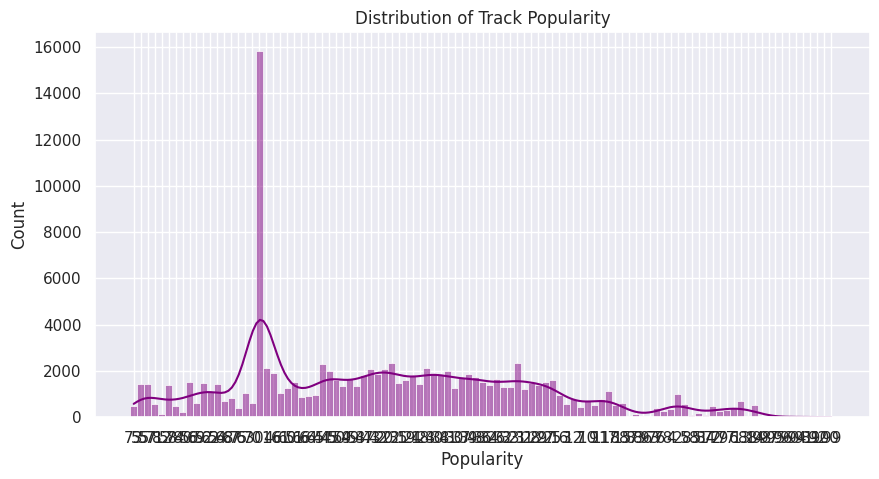

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], kde=True, bins=30, color='purple')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='danceability', ylabel='energy'>

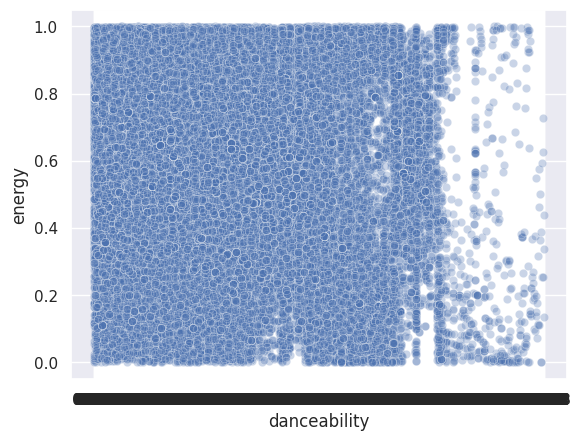

In [20]:
sns.scatterplot(data=df, x='danceability', y='energy', alpha=0.3)

<Axes: xlabel='track_genre', ylabel='popularity'>

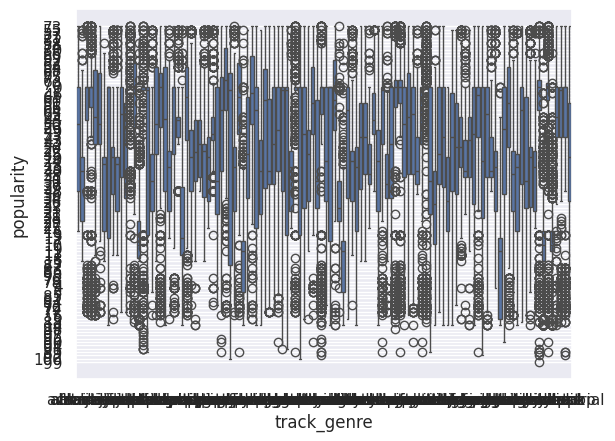

In [21]:
sns.boxplot(data=df, x='track_genre', y='popularity')

/tmp/ipykernel_1598/3538487928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['track_genre'].isin(top_genres)], x='track_genre', y='popularity', palette='Set2')


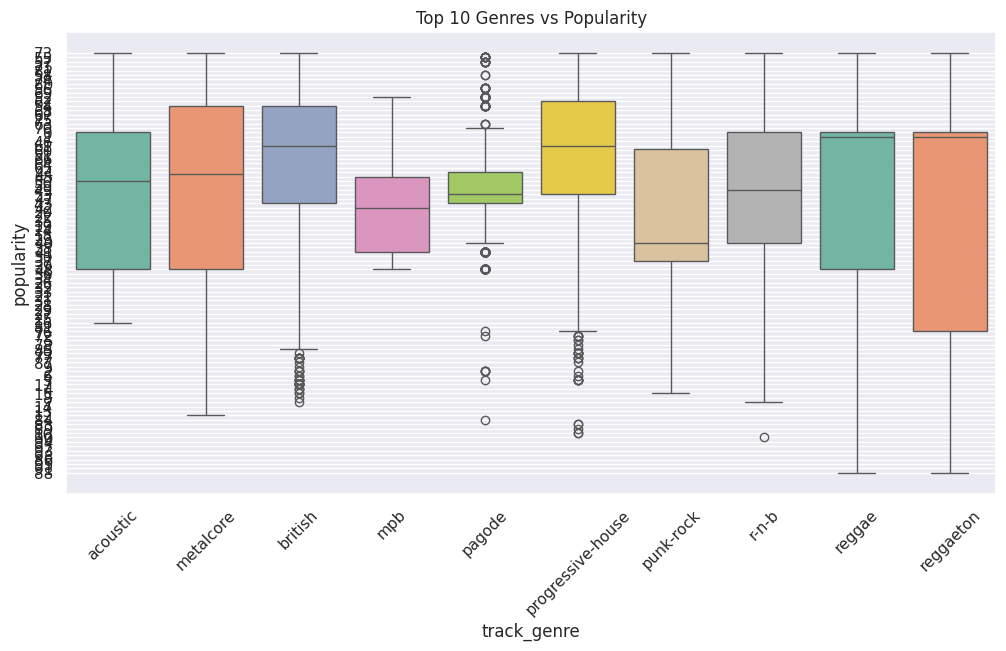

In [25]:
plt.figure(figsize=(12, 6))
top_genres = df['track_genre'].value_counts().head(10).index
sns.boxplot(data=df[df['track_genre'].isin(top_genres)], x='track_genre', y='popularity', palette='Set2')
plt.xticks(rotation=45)
plt.title('Top 10 Genres vs Popularity')
plt.show()

<Axes: >

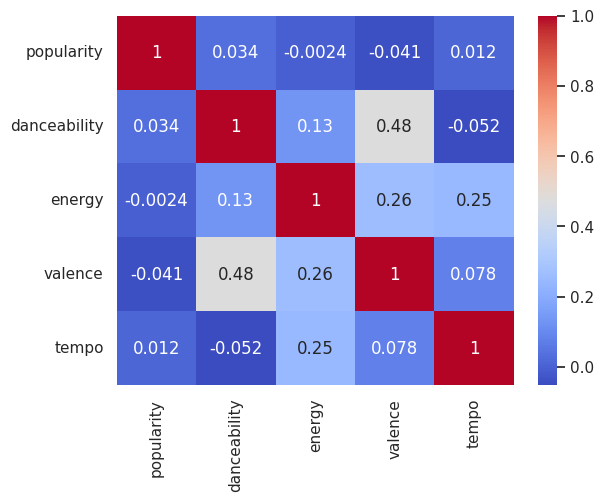

In [22]:
sns.heatmap(df[['popularity', 'danceability', 'energy', 'valence', 'tempo']].corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='loudness', ylabel='energy'>

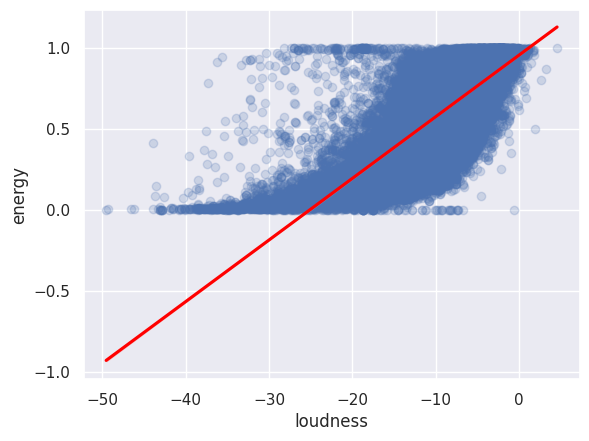

In [23]:
sns.regplot(data=df, x='loudness', y='energy', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})

<Axes: xlabel='artists'>

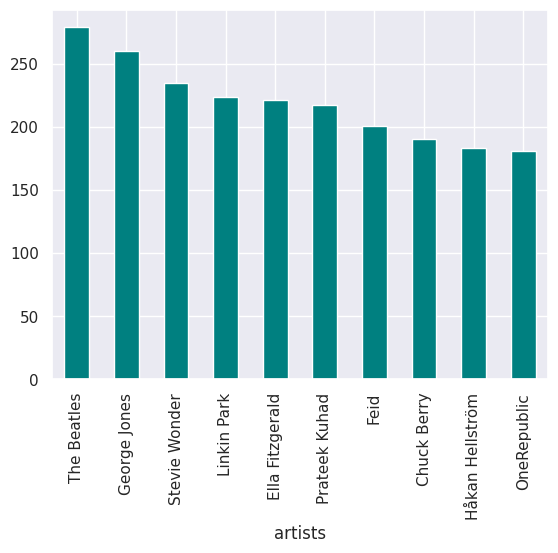

In [24]:
df['artists'].value_counts().head(10).plot(kind='bar', color='teal')